# 17. AI for Experiment Design and Power Planning

An experiment is not saved by a good readout if the design was weak. The most important causal decisions often happen before the first unit is randomized: who is eligible, what treatment means, which outcome is primary, what effect is worth detecting, what guardrails matter, and how the team will decide whether to ship, iterate, or stop.

This notebook shows how AI can help produce experiment-design artifacts while Python remains responsible for the statistical work. The LLM drafts and critiques. The analyst computes power, checks randomization, simulates assumptions, and audits the model's recommendations.

## Learning Goals

By the end of this notebook you should be able to:

1. Translate a business experiment request into an auditable experiment-design contract.
2. Compute minimum detectable effects for binary outcomes under two-arm randomization.
3. Explain why MDE is a design choice, not just a statistical formula.
4. Diagnose sample-ratio mismatch and pre-treatment covariate balance.
5. Use blocking and covariate adjustment to improve precision without changing the estimand.
6. Account for cluster randomization and intraclass correlation in power planning.
7. Simulate power under realistic outcome and treatment-effect assumptions.
8. Use local LLMs to critique an experiment plan while checking whether they overstate readiness.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal inference needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

Experiment-design notebooks are especially brittle because small language changes can imply large design changes. A model may say an experiment is "ready" while ignoring power, guardrails, eligibility leakage, interference, ramp risk, or sample-ratio mismatch. It may also produce valid JSON while giving weak design advice. We will make those risks explicit and score model outputs against deterministic design gates.

## 1. Setup

The deterministic part of the notebook uses local simulation and standard statistical approximations. The optional AI sections use local Hugging Face models through the shared helper utilities used in the rest of Course 05.

In [1]:
import importlib.util
import json
import sys
import textwrap
import warnings
from pathlib import Path
from statistics import NormalDist
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'
LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_STRONG_MODEL
MAX_NEW_TOKENS = 1900
TEMPERATURE = 0.0
SEED = 217
MODEL_COMPARISON_CASE_LIMIT = 2

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 160)

In [3]:
def has_package(module_name):
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'design and diagnostic tables'},
        {'package': 'numpy', 'available': has_package('numpy'), 'used_for': 'simulation and power calculations'},
        {'package': 'statsmodels', 'available': has_package('statsmodels'), 'used_for': 'covariate-adjusted readout model'},
        {'package': 'seaborn', 'available': has_package('seaborn'), 'used_for': 'plots'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI experiment review'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM review'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
package_status

CUDA available to this kernel: True


,package,available,used_for
0,pandas,True,design and diagnostic tables
1,numpy,True,simulation and power calculations
2,statsmodels,True,covariate-adjusted readout model
3,seaborn,True,plots
4,pydantic,True,structured AI experiment review
5,transformers,True,optional local LLM review
6,torch,True,GPU inference if live LLMs are enabled


## 2. Why Experiment Design Is a Causal Object

A randomized experiment identifies a causal effect because the treatment is assigned independently of potential outcomes. But that statement hides many design choices.

The causal estimand is not "the A/B test result." The estimand is something like:

$$
\mathbb{E}[Y_i(1) - Y_i(0) \mid i \in \mathcal{P}],
$$

where $\mathcal{P}$ is the eligible population, $Y_i(1)$ is the outcome under treatment, and $Y_i(0)$ is the outcome under control.

Power planning asks:

$$
\Pr(\text{reject } H_0 \mid \tau = \tau^*)
$$

for a practically meaningful effect $\tau^*$. The choice of $\tau^*$ is a business and scientific decision.

In [4]:
design_decisions = pd.DataFrame(
    [
        {'decision': 'Population', 'question': 'Who is eligible for randomization?', 'failure mode': 'The result answers the wrong deployment question.'},
        {'decision': 'Randomization unit', 'question': 'Users, accounts, stores, markets, or sessions?', 'failure mode': 'Interference or clustering makes uncertainty too optimistic.'},
        {'decision': 'Treatment definition', 'question': 'What exactly changes for treated units?', 'failure mode': 'The analysis estimates a vague product bundle.'},
        {'decision': 'Primary metric', 'question': 'Which outcome determines success?', 'failure mode': 'Metric shopping or post-hoc readout inflation.'},
        {'decision': 'MDE and power', 'question': 'What effect is worth detecting?', 'failure mode': 'An underpowered experiment is read as no effect.'},
        {'decision': 'Guardrails', 'question': 'What harm signals can block launch?', 'failure mode': 'A positive primary metric hides operational harm.'},
        {'decision': 'Decision rule', 'question': 'What will we do after the readout?', 'failure mode': 'Stakeholders negotiate with noisy results after seeing them.'},
    ]
)
design_decisions

,decision,question,failure mode
0,Population,Who is eligible for randomization?,The result answers the wrong deployment question.
1,Randomization unit,"Users, accounts, stores, markets, or sessions?",Interference or clustering makes uncertainty too optimistic.
2,Treatment definition,What exactly changes for treated units?,The analysis estimates a vague product bundle.
3,Primary metric,Which outcome determines success?,Metric shopping or post-hoc readout inflation.
4,MDE and power,What effect is worth detecting?,An underpowered experiment is read as no effect.
5,Guardrails,What harm signals can block launch?,A positive primary metric hides operational harm.
6,Decision rule,What will we do after the readout?,Stakeholders negotiate with noisy results after seeing them.


### Discussion

AI is useful here because experiment plans are documents. They contain assumptions, metric definitions, launch constraints, implementation risks, and stakeholder language. An LLM can help produce a first draft, ask for missing information, and map business language into causal design language.

But the LLM should not be the source of the power calculation. The notebook uses deterministic Python functions for that.

## 3. Running Example: AI Onboarding Checklist Experiment

A B2B SaaS company wants to test an AI-assisted onboarding checklist. The product team believes the checklist will help new accounts activate faster. The experiment should answer:

> What is the effect of showing an AI-assisted onboarding checklist on 14-day activation among newly eligible accounts?

The company can randomize at the account level. The primary metric is binary activation within 14 days. Guardrails include support-ticket creation, complaint events, and page latency.

In [5]:
experiment_contract = {
    'analysis_id': 'ai_onboarding_checklist_experiment_v1',
    'business_question': 'Should we launch an AI-assisted onboarding checklist to newly eligible accounts?',
    'estimand': 'ITT effect of checklist eligibility on 14-day account activation among newly eligible accounts',
    'population': 'newly eligible B2B SaaS accounts entering onboarding during the ramp window',
    'randomization_unit': 'account_id',
    'treatment': 'ai_onboarding_checklist',
    'control': 'standard_onboarding_homepage',
    'primary_metric': 'activated_within_14d',
    'primary_metric_type': 'binary',
    'baseline_activation_rate': 0.28,
    'business_mde_absolute': 0.015,
    'alpha': 0.05,
    'target_power': 0.80,
    'allocation_to_treatment': 0.50,
    'expected_eligible_accounts': 24000,
    'planned_duration_weeks': 4,
    'guardrail_metrics': [
        {'metric': 'support_tickets_14d', 'direction': 'increase is bad', 'threshold': 0.08},
        {'metric': 'complaint_event_14d', 'direction': 'increase is bad', 'threshold': 0.006},
        {'metric': 'page_latency_ms', 'direction': 'increase is bad', 'threshold': 75.0},
    ],
    'known_risks': [
        'Treatment may change support-ticket creation by encouraging more setup work.',
        'Account-level randomization is needed because users within the same account can share onboarding context.',
        'Activation is measured after treatment exposure, so no post-treatment covariates should be used in design checks.',
        'LLM-generated experiment plans can sound complete while omitting power or guardrail constraints.',
    ],
}

print(json.dumps(experiment_contract, indent=2))

{
  "analysis_id": "ai_onboarding_checklist_experiment_v1",
  "business_question": "Should we launch an AI-assisted onboarding checklist to newly eligible accounts?",
  "estimand": "ITT effect of checklist eligibility on 14-day account activation among newly eligible accounts",
  "population": "newly eligible B2B SaaS accounts entering onboarding during the ramp window",
  "randomization_unit": "account_id",
  "treatment": "ai_onboarding_checklist",
  "control": "standard_onboarding_homepage",
  "primary_metric": "activated_within_14d",
  "primary_metric_type": "binary",
  "baseline_activation_rate": 0.28,
  "business_mde_absolute": 0.015,
  "alpha": 0.05,
  "target_power": 0.8,
  "allocation_to_treatment": 0.5,
  "expected_eligible_accounts": 24000,
  "planned_duration_weeks": 4,
  "guardrail_metrics": [
    {
      "metric": "support_tickets_14d",
      "direction": "increase is bad",
      "threshold": 0.08
    },
    {
      "metric": "complaint_event_14d",
      "direction": "incr

## 4. Binary Outcome Power and MDE

For a two-arm experiment with a binary primary outcome, a simple planning approximation uses a normal approximation for the difference in proportions.

Let $p_0$ be the control activation rate, $p_1 = p_0 + \delta$ be the treatment activation rate, and $n_T$, $n_C$ be treatment and control sample sizes. A rough standard error under the alternative is

$$
\sqrt{\frac{p_1(1-p_1)}{n_T} + \frac{p_0(1-p_0)}{n_C}}.
$$

The MDE is the smallest $\delta$ that reaches target power for the planned sample size and alpha level. This is an approximation, not a guarantee. Later we compare it with simulation.

In [6]:
NORMAL = NormalDist()

def norm_cdf(x):
    return NORMAL.cdf(float(x))

def norm_ppf(p):
    return NORMAL.inv_cdf(float(p))

def analytic_power_binary(n_total, baseline_rate, absolute_effect, allocation=0.5, alpha=0.05):
    n_t = int(round(n_total * allocation))
    n_c = int(n_total - n_t)
    if n_t <= 1 or n_c <= 1:
        return np.nan
    p0 = float(np.clip(baseline_rate, 1e-6, 1 - 1e-6))
    p1 = float(np.clip(p0 + absolute_effect, 1e-6, 1 - 1e-6))
    effect = p1 - p0
    pooled = (n_t * p1 + n_c * p0) / (n_t + n_c)
    se_null = np.sqrt(pooled * (1 - pooled) * (1 / n_t + 1 / n_c))
    se_alt = np.sqrt(p1 * (1 - p1) / n_t + p0 * (1 - p0) / n_c)
    critical = norm_ppf(1 - alpha / 2) * se_null
    return float((1 - norm_cdf((critical - effect) / se_alt)) + norm_cdf((-critical - effect) / se_alt))

def mde_binary(n_total, baseline_rate, target_power=0.8, allocation=0.5, alpha=0.05, max_effect=0.20):
    low, high = 0.0, max_effect
    for _ in range(60):
        mid = (low + high) / 2
        if analytic_power_binary(n_total, baseline_rate, mid, allocation=allocation, alpha=alpha) >= target_power:
            high = mid
        else:
            low = mid
    return high

def required_n_for_mde(baseline_rate, mde, target_power=0.8, allocation=0.5, alpha=0.05, lower=200, upper=2_000_000):
    low, high = lower, upper
    while high - low > 1:
        mid = (low + high) // 2
        if analytic_power_binary(mid, baseline_rate, mde, allocation=allocation, alpha=alpha) >= target_power:
            high = mid
        else:
            low = mid
    return int(high)

In [7]:
planned_n = experiment_contract['expected_eligible_accounts']
baseline_rate = experiment_contract['baseline_activation_rate']
target_mde = experiment_contract['business_mde_absolute']
alpha = experiment_contract['alpha']
target_power = experiment_contract['target_power']
allocation = experiment_contract['allocation_to_treatment']

planned_power = analytic_power_binary(planned_n, baseline_rate, target_mde, allocation=allocation, alpha=alpha)
planned_mde = mde_binary(planned_n, baseline_rate, target_power=target_power, allocation=allocation, alpha=alpha)
required_n = required_n_for_mde(baseline_rate, target_mde, target_power=target_power, allocation=allocation, alpha=alpha)

power_summary = pd.DataFrame(
    [
        {'quantity': 'planned eligible accounts', 'value': planned_n},
        {'quantity': 'baseline activation rate', 'value': baseline_rate},
        {'quantity': 'business MDE absolute points', 'value': target_mde},
        {'quantity': 'analytic power at business MDE', 'value': planned_power},
        {'quantity': 'MDE at planned sample size', 'value': planned_mde},
        {'quantity': 'required N for business MDE at target power', 'value': required_n},
        {'quantity': 'sample-size gap', 'value': required_n - planned_n},
    ]
)
power_summary

,quantity,value
0,planned eligible accounts,24000.000000
1,baseline activation rate,0.280000
2,business MDE absolute points,0.015000
3,analytic power at business MDE,0.728175
4,MDE at planned sample size,0.016381
5,required N for business MDE at target power,28581.000000
6,sample-size gap,4581.000000


### Discussion

The design has a practical problem: the team cares about a 1.5 percentage point lift, but the planned sample size may not reliably detect it. This does not make the experiment useless. It means the readout must be honest about what the experiment can and cannot learn.

Possible responses include extending duration, increasing eligible population, accepting a larger MDE, using pre-treatment covariates to improve precision, or reframing the experiment as a ramp safety test rather than a definitive launch test.

In [8]:
sample_sizes = np.arange(6_000, 60_001, 6_000)
mde_table = pd.DataFrame(
    [
        {
            'total_n': int(n),
            'n_per_arm': int(round(n / 2)),
            'mde_for_80_power': mde_binary(n, baseline_rate, target_power=target_power, allocation=allocation, alpha=alpha),
            'power_for_business_mde': analytic_power_binary(n, baseline_rate, target_mde, allocation=allocation, alpha=alpha),
        }
        for n in sample_sizes
    ]
)
mde_table

,total_n,n_per_arm,mde_for_80_power,power_for_business_mde
0,6000,3000,0.033031,0.249961
1,12000,6000,0.023246,0.442547
2,18000,9000,0.018939,0.603859
3,24000,12000,0.016381,0.728175
4,30000,15000,0.014638,0.818682
5,36000,18000,0.013354,0.881860
6,42000,21000,0.012357,0.924540
7,48000,24000,0.011554,0.952619
8,54000,27000,0.010889,0.970692
9,60000,30000,0.010328,0.982109


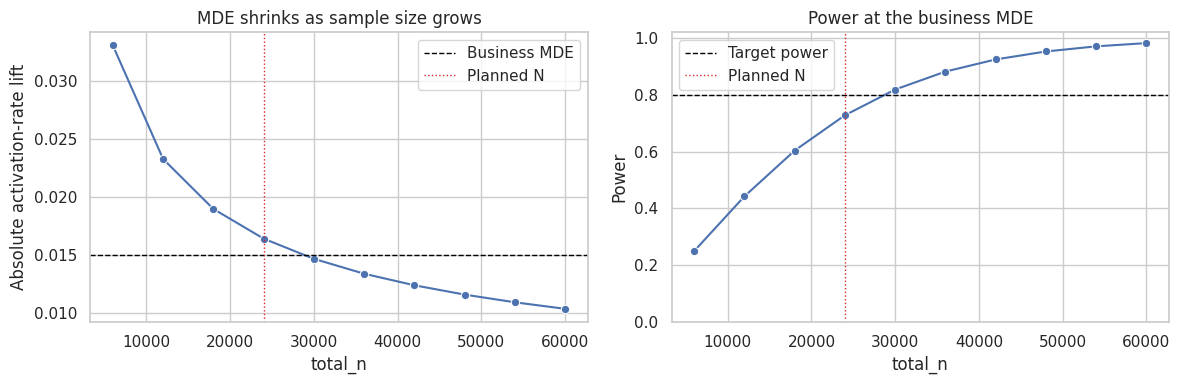

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=mde_table, x='total_n', y='mde_for_80_power', marker='o', ax=axes[0])
axes[0].axhline(target_mde, color='black', linestyle='--', linewidth=1, label='Business MDE')
axes[0].axvline(planned_n, color='tab:red', linestyle=':', linewidth=1, label='Planned N')
axes[0].set_title('MDE shrinks as sample size grows')
axes[0].set_ylabel('Absolute activation-rate lift')
axes[0].legend()

sns.lineplot(data=mde_table, x='total_n', y='power_for_business_mde', marker='o', ax=axes[1])
axes[1].axhline(target_power, color='black', linestyle='--', linewidth=1, label='Target power')
axes[1].axvline(planned_n, color='tab:red', linestyle=':', linewidth=1, label='Planned N')
axes[1].set_title('Power at the business MDE')
axes[1].set_ylabel('Power')
axes[1].set_ylim(0, 1.02)
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Allocation Ratios and Ramp Plans

Equal allocation is usually most efficient when treatment and control units have similar cost and variance. Sometimes product constraints require unequal traffic, such as a 10 percent ramp. That is fine for safety learning, but it reduces power for a fixed total sample size.

In [10]:
allocation_table = pd.DataFrame(
    [
        {
            'treatment_allocation': a,
            'control_n': int(round(planned_n * (1 - a))),
            'treatment_n': int(round(planned_n * a)),
            'mde_for_80_power': mde_binary(planned_n, baseline_rate, target_power=target_power, allocation=a, alpha=alpha),
            'power_for_business_mde': analytic_power_binary(planned_n, baseline_rate, target_mde, allocation=a, alpha=alpha),
        }
        for a in [0.05, 0.10, 0.20, 0.30, 0.50]
    ]
)
allocation_table

,treatment_allocation,control_n,treatment_n,mde_for_80_power,power_for_business_mde
0,0.05,22800,1200,0.037702,0.206891
1,0.10,21600,2400,0.027324,0.343079
2,0.20,19200,4800,0.020465,0.540886
3,0.30,16800,7200,0.017859,0.654643
4,0.50,12000,12000,0.016381,0.728175


### Discussion

A 5 percent or 10 percent allocation is useful for a ramp, but it is not a replacement for a powered experiment. A common industry workflow is: start small to detect implementation harm, move to larger allocation once guardrails look stable, and keep the analysis plan fixed before looking at the primary outcome.

## 6. Simulating the Experiment Population

Power formulas compress the world into a baseline rate, an effect size, and a sample size. Simulation lets us include heterogeneity, pre-treatment predictors, blocking, guardrails, and decision rules.

The simulated data below has known potential outcomes, but the analysis only uses observed outcomes after randomization.

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def assign_blocked_treatment(df, block_col='block', allocation=0.5, seed=SEED):
    rng = np.random.default_rng(seed)
    assigned = df.copy()
    treatment = np.zeros(len(assigned), dtype=int)
    for _, idx in assigned.groupby(block_col).groups.items():
        idx = np.array(list(idx))
        shuffled = rng.permutation(idx)
        n_t = int(round(len(shuffled) * allocation))
        treatment[shuffled[:n_t]] = 1
    assigned['ai_onboarding_checklist'] = treatment
    return assigned


def simulate_account_population(n=planned_n, seed=SEED, treatment_effect=target_mde, allocation=0.5, blocked=True):
    rng = np.random.default_rng(seed)
    segment = rng.choice(['startup', 'midmarket', 'enterprise'], size=n, p=[0.50, 0.36, 0.14])
    region = rng.choice(['Americas', 'EMEA', 'APAC'], size=n, p=[0.49, 0.32, 0.19])
    acquisition_channel = rng.choice(['sales_led', 'self_serve', 'partner'], size=n, p=[0.42, 0.44, 0.14])
    baseline_usage = rng.normal(0, 1, size=n)
    seats_purchased = np.maximum(1, rng.poisson(6 + 5 * (segment == 'enterprise') + 2 * (segment == 'midmarket')))
    prior_touchpoints = rng.poisson(np.exp(0.25 + 0.16 * (acquisition_channel == 'sales_led') - 0.10 * baseline_usage), size=n)
    pre_period_score = (
        0.55 * baseline_usage
        + 0.18 * np.log1p(seats_purchased)
        + 0.25 * (acquisition_channel == 'sales_led')
        + 0.12 * (region == 'Americas')
        + rng.normal(0, 0.70, size=n)
    )
    base_logit = (
        -0.98
        + 0.55 * pre_period_score
        + 0.28 * (segment == 'enterprise')
        + 0.14 * (segment == 'midmarket')
        + 0.16 * (acquisition_channel == 'sales_led')
        - 0.06 * prior_touchpoints
    )
    p0 = sigmoid(base_logit)
    heterogeneity_raw = 0.006 * (segment == 'enterprise') + 0.004 * (pre_period_score > 0.8)
    heterogeneous_effect = treatment_effect + heterogeneity_raw - heterogeneity_raw.mean()
    p1 = np.clip(p0 + heterogeneous_effect, 0.001, 0.999)
    block = pd.Series(segment).astype(str) + '_' + pd.Series(region).astype(str)
    df = pd.DataFrame(
        {
            'account_id': np.arange(n),
            'segment': segment,
            'region': region,
            'acquisition_channel': acquisition_channel,
            'baseline_usage': baseline_usage,
            'seats_purchased': seats_purchased,
            'prior_touchpoints': prior_touchpoints,
            'pre_period_score': pre_period_score,
            'block': block,
            'p0_activation': p0,
            'p1_activation': p1,
            'true_individual_effect': p1 - p0,
        }
    )
    if blocked:
        df = assign_blocked_treatment(df, allocation=allocation, seed=seed + 11)
    else:
        df['ai_onboarding_checklist'] = rng.binomial(1, allocation, size=n)
    p_obs = np.where(df['ai_onboarding_checklist'].to_numpy() == 1, p1, p0)
    df['activated_within_14d'] = rng.binomial(1, p_obs)
    df['support_tickets_14d'] = rng.poisson(np.exp(-0.35 + 0.16 * df['ai_onboarding_checklist'] + 0.12 * prior_touchpoints - 0.10 * pre_period_score))
    df['complaint_event_14d'] = rng.binomial(1, sigmoid(-5.25 + 0.18 * df['ai_onboarding_checklist'] + 0.08 * prior_touchpoints))
    df['page_latency_ms'] = rng.normal(214 + 23 * df['ai_onboarding_checklist'] + 8 * (region == 'APAC'), 28, size=n).clip(90)
    return df

experiment_df = simulate_account_population()
experiment_df.head()

,account_id,segment,region,acquisition_channel,baseline_usage,seats_purchased,prior_touchpoints,pre_period_score,block,p0_activation,p1_activation,true_individual_effect,ai_onboarding_checklist,activated_within_14d,support_tickets_14d,complaint_event_14d,page_latency_ms
0,0,midmarket,Americas,partner,0.579605,9,2,-0.664912,midmarket_Americas,0.209871,0.222512,0.012641,1,0,1,0,302.294323
1,1,midmarket,Americas,sales_led,1.467769,12,2,1.065136,midmarket_Americas,0.446660,0.463301,0.016641,0,1,2,0,226.018450
2,2,midmarket,Americas,sales_led,0.890885,7,2,0.599862,midmarket_Americas,0.384598,0.397239,0.012641,1,1,0,0,244.106051
3,3,midmarket,Americas,self_serve,1.137704,6,0,0.870284,midmarket_Americas,0.410634,0.427275,0.016641,0,1,2,0,232.177793
4,4,startup,Americas,self_serve,0.597827,9,2,0.803312,startup_Americas,0.341149,0.357790,0.016641,0,0,1,0,180.491935


In [12]:
population_summary = pd.DataFrame(
    [
        {'quantity': 'rows', 'value': len(experiment_df)},
        {'quantity': 'treatment share', 'value': experiment_df['ai_onboarding_checklist'].mean()},
        {'quantity': 'observed control activation', 'value': experiment_df.loc[experiment_df['ai_onboarding_checklist'] == 0, 'activated_within_14d'].mean()},
        {'quantity': 'observed treatment activation', 'value': experiment_df.loc[experiment_df['ai_onboarding_checklist'] == 1, 'activated_within_14d'].mean()},
        {'quantity': 'true ATE in simulated population', 'value': experiment_df['true_individual_effect'].mean()},
    ]
)
population_summary

,quantity,value
0,rows,24000.000000
1,treatment share,0.500042
2,observed control activation,0.355280
3,observed treatment activation,0.369553
4,true ATE in simulated population,0.015000


## 7. Randomization Checks: SRM and Balance

A sample-ratio mismatch check asks whether the observed treatment allocation is suspiciously far from the planned allocation. Balance checks ask whether pre-treatment covariates are similar across treatment arms. In a properly randomized experiment, modest imbalance can happen by chance, but large imbalance can reveal implementation bugs.

In [13]:
def sample_ratio_check(treatment, expected_treatment_share=0.5):
    treatment = np.asarray(treatment)
    n = len(treatment)
    observed_t = treatment.sum()
    expected_t = n * expected_treatment_share
    variance = n * expected_treatment_share * (1 - expected_treatment_share)
    z = (observed_t - expected_t) / np.sqrt(variance)
    p_value = 2 * (1 - norm_cdf(abs(z)))
    return {
        'n': int(n),
        'observed_treatment': int(observed_t),
        'expected_treatment': float(expected_t),
        'observed_treatment_share': float(observed_t / n),
        'z_stat': float(z),
        'p_value': float(p_value),
        'status': 'fail' if p_value < 0.001 else 'ok',
    }

sample_ratio_check(experiment_df['ai_onboarding_checklist'], allocation)

{'n': 24000,
 'observed_treatment': 12001,
 'expected_treatment': 12000.0,
 'observed_treatment_share': 0.5000416666666667,
 'z_stat': 0.012909944487358056,
 'p_value': 0.9896996407346004,
 'status': 'ok'}

In [14]:
def standardized_mean_difference(df, treatment_col, covariate):
    treated = df.loc[df[treatment_col] == 1, covariate]
    control = df.loc[df[treatment_col] == 0, covariate]
    pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return 0.0
    return float((treated.mean() - control.mean()) / pooled_sd)


def balance_table(df, treatment_col, numeric_covariates, categorical_covariates):
    rows = []
    for cov in numeric_covariates:
        rows.append({'covariate': cov, 'smd': standardized_mean_difference(df, treatment_col, cov), 'type': 'numeric'})
    for cov in categorical_covariates:
        for level in sorted(df[cov].unique()):
            indicator = f'{cov}_{level}'
            temp = df.assign(**{indicator: (df[cov] == level).astype(int)})
            rows.append({'covariate': indicator, 'smd': standardized_mean_difference(temp, treatment_col, indicator), 'type': 'categorical'})
    out = pd.DataFrame(rows)
    out['abs_smd'] = out['smd'].abs()
    return out.sort_values('abs_smd', ascending=False).reset_index(drop=True)

pre_treatment_numeric = ['baseline_usage', 'seats_purchased', 'prior_touchpoints', 'pre_period_score']
pre_treatment_categorical = ['segment', 'region', 'acquisition_channel']
experiment_balance = balance_table(experiment_df, 'ai_onboarding_checklist', pre_treatment_numeric, pre_treatment_categorical)
experiment_balance.head(12)

,covariate,smd,type,abs_smd
0,acquisition_channel_self_serve,-0.015930,categorical,0.015930
1,acquisition_channel_sales_led,0.012681,categorical,0.012681
2,seats_purchased,0.009825,numeric,0.009825
3,prior_touchpoints,-0.009044,numeric,0.009044
4,acquisition_channel_partner,0.004759,categorical,0.004759
5,pre_period_score,0.004176,numeric,0.004176
6,baseline_usage,0.000597,numeric,0.000597
7,segment_enterprise,0.000419,categorical,0.000419
8,segment_startup,-0.000333,categorical,0.000333
9,region_APAC,-0.000081,categorical,0.000081


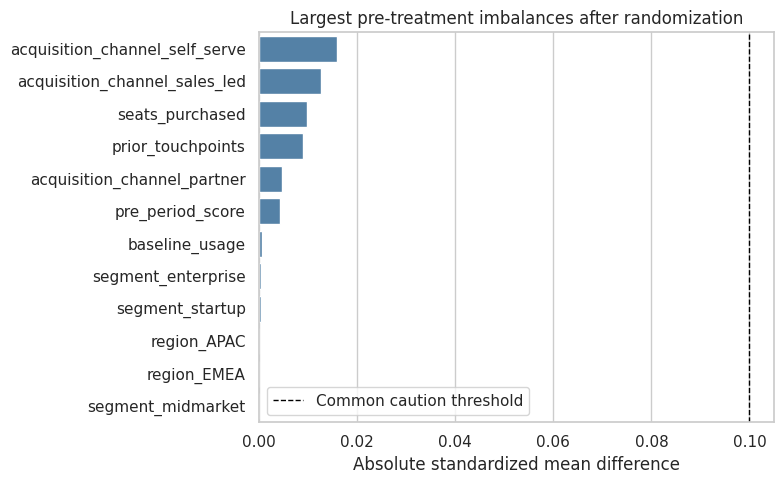

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=experiment_balance.head(12), y='covariate', x='abs_smd', color='steelblue')
plt.axvline(0.10, color='black', linestyle='--', linewidth=1, label='Common caution threshold')
plt.title('Largest pre-treatment imbalances after randomization')
plt.xlabel('Absolute standardized mean difference')
plt.ylabel('')
plt.legend()
plt.tight_layout()
plt.show()

### Discussion

In randomized experiments, balance is a diagnostic for implementation quality, not a requirement for identification in the same way it is in observational studies. SRM is often the more urgent industry diagnostic because it can reveal dropped events, targeting bugs, bot filtering differences, assignment-service problems, or inconsistent eligibility logic.

## 8. Primary Readout and Covariate Adjustment

The simplest readout is a difference in means. For a binary outcome, that difference is the difference in activation rates. We also fit a covariate-adjusted linear probability model for transparency. The estimand remains the ITT effect of assignment; pre-treatment covariates are used only for precision.

In [16]:
def two_sample_difference_test(df, outcome, treatment_col):
    treated = df.loc[df[treatment_col] == 1, outcome].astype(float)
    control = df.loc[df[treatment_col] == 0, outcome].astype(float)
    diff = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / len(treated) + control.var(ddof=1) / len(control))
    z = diff / se if se > 0 else np.nan
    p_value = 2 * (1 - norm_cdf(abs(z))) if np.isfinite(z) else np.nan
    return {
        'control_mean': float(control.mean()),
        'treatment_mean': float(treated.mean()),
        'difference': float(diff),
        'standard_error': float(se),
        'ci_low': float(diff - norm_ppf(0.975) * se),
        'ci_high': float(diff + norm_ppf(0.975) * se),
        'p_value': float(p_value),
        'n_control': int(len(control)),
        'n_treatment': int(len(treated)),
    }

primary_naive = two_sample_difference_test(experiment_df, 'activated_within_14d', 'ai_onboarding_checklist')
primary_naive

{'control_mean': 0.35527960663388614,
 'treatment_mean': 0.3695525372885593,
 'difference': 0.014272930654673166,
 'standard_error': 0.006205358232884456,
 'ci_low': 0.0021106520070505227,
 'ci_high': 0.026435209302295808,
 'p_value': 0.021442681403956332,
 'n_control': 11999,
 'n_treatment': 12001}

In [17]:
def fit_adjusted_primary_model(df):
    formula = (
        'activated_within_14d ~ ai_onboarding_checklist + baseline_usage + seats_purchased + '
        'prior_touchpoints + pre_period_score + C(segment) + C(region) + C(acquisition_channel)'
    )
    model = smf.ols(formula, data=df).fit(cov_type='HC1')
    coef = model.params['ai_onboarding_checklist']
    se = model.bse['ai_onboarding_checklist']
    return {
        'formula': formula,
        'estimate': float(coef),
        'robust_se': float(se),
        'ci_low': float(coef - norm_ppf(0.975) * se),
        'ci_high': float(coef + norm_ppf(0.975) * se),
        'p_value': float(model.pvalues['ai_onboarding_checklist']),
        'rows': int(model.nobs),
    }

primary_adjusted = fit_adjusted_primary_model(experiment_df)
primary_adjusted

{'formula': 'activated_within_14d ~ ai_onboarding_checklist + baseline_usage + seats_purchased + prior_touchpoints + pre_period_score + C(segment) + C(region) + C(acquisition_channel)',
 'estimate': 0.01341723707775179,
 'robust_se': 0.006020516494614477,
 'ci_low': 0.001617241579978083,
 'ci_high': 0.025217232575525494,
 'p_value': 0.02584148215799596,
 'rows': 24000}

### Discussion

The adjusted model should be specified before the experiment readout. Otherwise covariate adjustment can become another form of researcher degrees of freedom. Use only pre-treatment covariates, report both unadjusted and adjusted estimates, and do not change the primary decision rule after seeing results.

## 9. CUPED-Style Precision Gain

CUPED-style adjustment subtracts predictable outcome variation using pre-treatment information:

$$
Y_i^{adj} = Y_i - \theta(X_i - \bar{X}).
$$

If $X$ predicts $Y$, this can reduce variance and improve power. It does not fix post-treatment bias; it is a precision tool.

In [18]:
def cuped_adjusted_outcome(df, outcome, covariate):
    y = df[outcome].astype(float).to_numpy()
    x = df[covariate].astype(float).to_numpy()
    theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)
    adjusted = y - theta * (x - x.mean())
    return adjusted, float(theta), float(np.corrcoef(y, x)[0, 1])

adjusted_y, theta, corr_y_x = cuped_adjusted_outcome(experiment_df, 'activated_within_14d', 'pre_period_score')
experiment_df = experiment_df.assign(activated_cuped=adjusted_y)
primary_cuped = two_sample_difference_test(experiment_df, 'activated_cuped', 'ai_onboarding_checklist')

cuped_summary = pd.DataFrame(
    [
        {'method': 'unadjusted difference', **primary_naive},
        {'method': 'CUPED adjusted difference', **primary_cuped},
    ]
)
print(f'CUPED theta: {theta:.4f}; corr(outcome, pre_period_score): {corr_y_x:.3f}')
cuped_summary[['method', 'difference', 'standard_error', 'ci_low', 'ci_high', 'p_value']]

CUPED theta: 0.1249; corr(outcome, pre_period_score): 0.236


,method,difference,standard_error,ci_low,ci_high,p_value
0,unadjusted difference,0.014273,0.006205,0.002111,0.026435,0.021443
1,CUPED adjusted difference,0.013800,0.006031,0.001980,0.025620,0.022121


### Discussion

The point estimate can move slightly because this is one realized experiment. The main design lesson is precision. If a pre-treatment score predicts activation, adjustment can reduce standard errors and lower the MDE for the same sample size.

This is a point where an LLM can be dangerous. It may describe CUPED as removing confounding. In a randomized experiment, the point is precision improvement.

## 10. Monte Carlo Power Under Realistic Data Generation

Analytic power is useful but simple. Simulation lets us ask: if the world looked like this, how often would our planned analysis detect the effect?

In [19]:
def experiment_p_value(df, use_cuped=False):
    if use_cuped:
        adjusted, _, _ = cuped_adjusted_outcome(df, 'activated_within_14d', 'pre_period_score')
        temp = df.assign(activated_cuped=adjusted)
        return two_sample_difference_test(temp, 'activated_cuped', 'ai_onboarding_checklist')
    return two_sample_difference_test(df, 'activated_within_14d', 'ai_onboarding_checklist')


def run_power_simulation(n_total, effect, n_sims=160, seed=SEED, use_cuped=False, blocked=True):
    rng = np.random.default_rng(seed)
    rows = []
    for sim in range(n_sims):
        sim_seed = int(rng.integers(1, 2_000_000_000))
        df = simulate_account_population(n=n_total, seed=sim_seed, treatment_effect=effect, allocation=allocation, blocked=blocked)
        result = experiment_p_value(df, use_cuped=use_cuped)
        rows.append(
            {
                'sim': sim,
                'estimate': result['difference'],
                'standard_error': result['standard_error'],
                'p_value': result['p_value'],
                'significant': result['p_value'] < alpha,
                'use_cuped': use_cuped,
                'n_total': n_total,
                'effect': effect,
            }
        )
    return pd.DataFrame(rows)

sim_unadjusted = run_power_simulation(planned_n, target_mde, n_sims=160, seed=SEED + 100, use_cuped=False)
sim_cuped = run_power_simulation(planned_n, target_mde, n_sims=160, seed=SEED + 100, use_cuped=True)

simulation_summary = pd.concat([sim_unadjusted, sim_cuped]).groupby('use_cuped', as_index=False).agg(
    simulated_power=('significant', 'mean'),
    mean_estimate=('estimate', 'mean'),
    sd_estimate=('estimate', 'std'),
    mean_standard_error=('standard_error', 'mean'),
)
simulation_summary['analysis'] = np.where(simulation_summary['use_cuped'], 'CUPED adjusted', 'unadjusted')
simulation_summary[['analysis', 'simulated_power', 'mean_estimate', 'sd_estimate', 'mean_standard_error']]

,analysis,simulated_power,mean_estimate,sd_estimate,mean_standard_error
0,unadjusted,0.70625,0.015471,0.005838,0.006225
1,CUPED adjusted,0.73125,0.015601,0.005853,0.006052


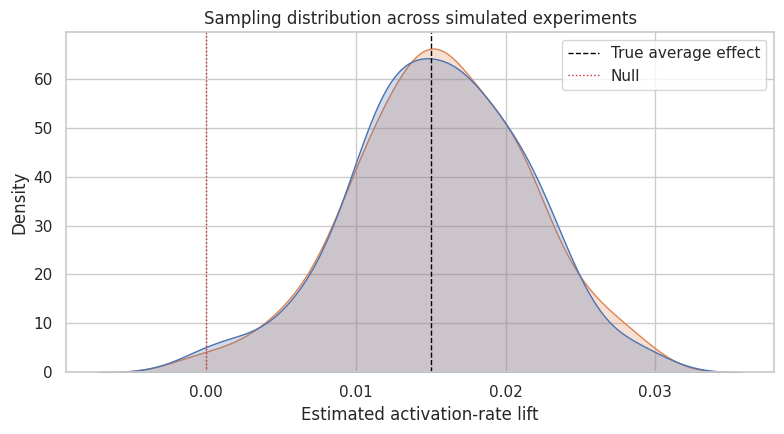

In [20]:
sim_plot = pd.concat([sim_unadjusted, sim_cuped]).assign(
    analysis=lambda d: np.where(d['use_cuped'], 'CUPED adjusted', 'unadjusted')
)

plt.figure(figsize=(8, 4.5))
sns.kdeplot(data=sim_plot, x='estimate', hue='analysis', fill=True, common_norm=False, alpha=0.25)
plt.axvline(target_mde, color='black', linestyle='--', linewidth=1, label='True average effect')
plt.axvline(0, color='tab:red', linestyle=':', linewidth=1, label='Null')
plt.title('Sampling distribution across simulated experiments')
plt.xlabel('Estimated activation-rate lift')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Simulation Power Curve

We can estimate power across different sample sizes under the same simulated data-generating process. The exact numbers are Monte Carlo estimates, so they move a little across reruns. That is another useful form of brittleness: simulation power is itself estimated with uncertainty.

In [21]:
power_curve_rows = []
for n in [8_000, 12_000, 16_000, 20_000, 24_000, 32_000, 40_000]:
    sims = run_power_simulation(n, target_mde, n_sims=70, seed=SEED + n, use_cuped=False)
    sims_cuped = run_power_simulation(n, target_mde, n_sims=70, seed=SEED + n, use_cuped=True)
    power_curve_rows.append({'total_n': n, 'analysis': 'unadjusted', 'simulated_power': sims['significant'].mean()})
    power_curve_rows.append({'total_n': n, 'analysis': 'CUPED adjusted', 'simulated_power': sims_cuped['significant'].mean()})

simulation_power_curve = pd.DataFrame(power_curve_rows)
simulation_power_curve

,total_n,analysis,simulated_power
0,8000,unadjusted,0.328571
1,8000,CUPED adjusted,0.342857
2,12000,unadjusted,0.328571
3,12000,CUPED adjusted,0.342857
4,16000,unadjusted,0.442857
5,16000,CUPED adjusted,0.500000
6,20000,unadjusted,0.614286
7,20000,CUPED adjusted,0.600000
8,24000,unadjusted,0.585714
9,24000,CUPED adjusted,0.614286


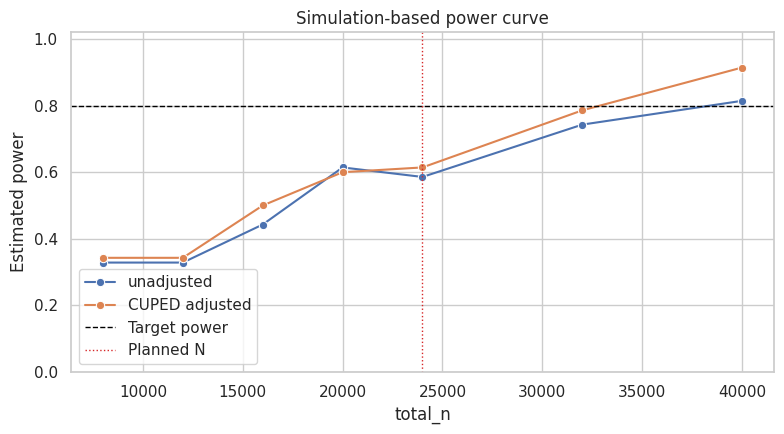

In [22]:
plt.figure(figsize=(8, 4.5))
sns.lineplot(data=simulation_power_curve, x='total_n', y='simulated_power', hue='analysis', marker='o')
plt.axhline(target_power, color='black', linestyle='--', linewidth=1, label='Target power')
plt.axvline(planned_n, color='tab:red', linestyle=':', linewidth=1, label='Planned N')
plt.ylim(0, 1.02)
plt.title('Simulation-based power curve')
plt.ylabel('Estimated power')
plt.legend()
plt.tight_layout()
plt.show()

### Discussion

Simulation-based power is not more true than analytic power. It is more customizable. It inherits assumptions about the data-generating process, outcome model, treatment heterogeneity, missingness, and analysis method.

AI can help by asking design questions: do effects vary by segment, is there an operational cap, are outcomes delayed beyond the readout window, are accounts independent, and is the pre-treatment score available before randomization?

## 12. Cluster Randomization and Design Effects

Sometimes we cannot randomize individual users or accounts. We may randomize sales reps, stores, markets, classrooms, or customer-success managers. Cluster randomization reduces effective sample size when outcomes are correlated within clusters.

A simple design effect approximation is

$$
DE = 1 + (m - 1)\rho,
$$

where $m$ is average cluster size and $\rho$ is the intraclass correlation. Effective sample size is approximately $n / DE$.

In [23]:
def design_effect(avg_cluster_size, icc):
    return 1 + (avg_cluster_size - 1) * icc

cluster_table = pd.DataFrame(
    [
        {
            'avg_cluster_size': m,
            'icc': icc,
            'design_effect': design_effect(m, icc),
            'effective_n_at_planned_n': planned_n / design_effect(m, icc),
            'mde_for_effective_n': mde_binary(planned_n / design_effect(m, icc), baseline_rate, target_power=target_power, allocation=allocation, alpha=alpha),
        }
        for m in [5, 10, 25, 50, 100]
        for icc in [0.001, 0.005, 0.010, 0.025]
    ]
)
cluster_table.head(12)

,avg_cluster_size,icc,design_effect,effective_n_at_planned_n,mde_for_effective_n
0,5,0.001,1.004,23904.382470,0.016414
1,5,0.005,1.020,23529.411765,0.016545
2,5,0.010,1.040,23076.923077,0.016708
3,5,0.025,1.100,21818.181818,0.017187
4,10,0.001,1.009,23785.926660,0.016455
5,10,0.005,1.045,22966.507177,0.016748
6,10,0.010,1.090,22018.348624,0.017108
7,10,0.025,1.225,19591.836735,0.018147
8,25,0.001,1.024,23437.500000,0.016578
9,25,0.005,1.120,21428.571429,0.017344


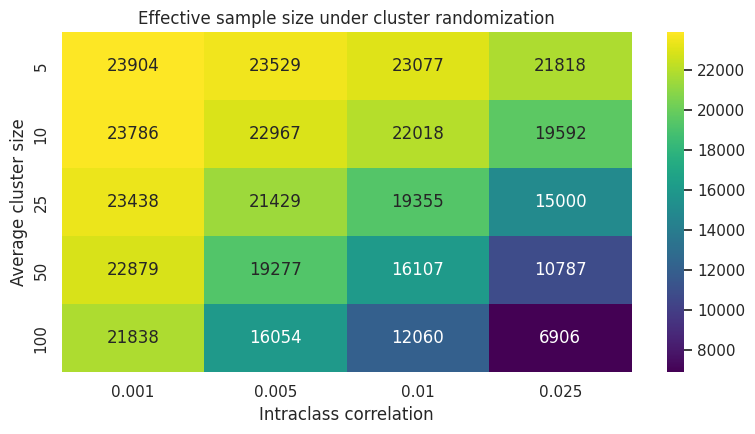

In [24]:
pivot = cluster_table.pivot(index='avg_cluster_size', columns='icc', values='effective_n_at_planned_n')
plt.figure(figsize=(8, 4.5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='viridis')
plt.title('Effective sample size under cluster randomization')
plt.xlabel('Intraclass correlation')
plt.ylabel('Average cluster size')
plt.tight_layout()
plt.show()

### Discussion

A model that ignores clustering can recommend a launch-ready design that is wildly underpowered. If the randomization unit is larger than the analysis unit, power planning must reflect that. If treatment spills over between users in the same account, individual-level randomization can also violate no-interference assumptions.

## 13. Guardrails and Ramp Decision Rules

A good experiment plan defines what success means before the readout. Here we care about activation, but we also care about support load, complaints, and latency. A reasonable launch rule should not ship the treatment if guardrails fail badly.

In [25]:
def summarize_metric_difference(df, metric, treatment_col='ai_onboarding_checklist'):
    result = two_sample_difference_test(df, metric, treatment_col)
    return {
        'metric': metric,
        'control_mean': result['control_mean'],
        'treatment_mean': result['treatment_mean'],
        'difference': result['difference'],
        'ci_low': result['ci_low'],
        'ci_high': result['ci_high'],
        'p_value': result['p_value'],
    }

metric_readout = pd.DataFrame(
    [
        summarize_metric_difference(experiment_df, 'activated_within_14d'),
        summarize_metric_difference(experiment_df, 'support_tickets_14d'),
        summarize_metric_difference(experiment_df, 'complaint_event_14d'),
        summarize_metric_difference(experiment_df, 'page_latency_ms'),
    ]
)
metric_readout

,metric,control_mean,treatment_mean,difference,ci_low,ci_high,p_value
0,activated_within_14d,0.355280,0.369553,0.014273,0.002111,0.026435,0.021443
1,support_tickets_14d,0.804484,0.935422,0.130938,0.106785,0.155091,0.000000
2,complaint_event_14d,0.006084,0.007583,0.001499,-0.000586,0.003583,0.158737
3,page_latency_ms,215.398452,238.558229,23.159776,22.450156,23.869397,0.000000


In [26]:
def classify_guardrails(readout, contract):
    rows = []
    for guardrail in contract['guardrail_metrics']:
        metric = guardrail['metric']
        threshold = guardrail['threshold']
        row = readout.loc[readout['metric'] == metric].iloc[0]
        diff = float(row['difference'])
        ci_high = float(row['ci_high'])
        if guardrail['direction'] == 'increase is bad':
            if ci_high > threshold:
                status = 'fail'
            elif diff > 0.5 * threshold:
                status = 'caution'
            else:
                status = 'pass'
        else:
            status = 'needs_manual_review'
        rows.append({'metric': metric, 'difference': diff, 'ci_high': ci_high, 'threshold': threshold, 'status': status})
    return pd.DataFrame(rows)


def experiment_decision(primary_result, guardrail_table, srm_result, power_at_mde):
    if srm_result['status'] == 'fail':
        return 'do_not_read_out_until_assignment_bug_is_resolved'
    if (guardrail_table['status'] == 'fail').any():
        return 'do_not_launch_due_to_guardrail_failure'
    if power_at_mde < 0.75:
        return 'continue_or_extend_before_final_decision'
    if primary_result['p_value'] < alpha and primary_result['difference'] > 0:
        if (guardrail_table['status'] == 'caution').any():
            return 'ship_with_guardrail_monitoring'
        return 'ship'
    return 'do_not_ship_yet_or_continue_learning'

guardrail_table = classify_guardrails(metric_readout, experiment_contract)
srm_result = sample_ratio_check(experiment_df['ai_onboarding_checklist'], allocation)
decision = experiment_decision(primary_naive, guardrail_table, srm_result, planned_power)

display(guardrail_table)
print('Decision:', decision)

,metric,difference,ci_high,threshold,status
0,support_tickets_14d,0.130938,0.155091,0.080,fail
1,complaint_event_14d,0.001499,0.003583,0.006,pass
2,page_latency_ms,23.159776,23.869397,75.000,pass


Decision: do_not_launch_due_to_guardrail_failure


### Discussion

Decision rules force the team to confront tradeoffs before seeing results. If the primary metric wins but complaints or latency fail, the plan should already say what happens.

This is another teaching opportunity for AI brittleness. LLMs often write persuasive launch summaries from a positive primary metric while underweighting guardrails. A good AI workflow must explicitly feed guardrail results into the prompt and score whether the model respects them.

## 14. Machine-Readable Experiment Design Report

Before involving an LLM, we build a compact report that contains the design contract, power analysis, randomization diagnostics, metric readout, and deterministic recommendation.

In [27]:
def dataframe_records(df, digits=6):
    return json.loads(df.round(digits).to_json(orient='records'))

experiment_design_report = {
    'experiment_contract': experiment_contract,
    'analytic_power_summary': {
        'planned_n': planned_n,
        'baseline_rate': baseline_rate,
        'business_mde_absolute': target_mde,
        'planned_power_at_business_mde': planned_power,
        'mde_at_planned_n': planned_mde,
        'required_n_for_business_mde': required_n,
        'sample_size_gap': required_n - planned_n,
    },
    'allocation_sensitivity': dataframe_records(allocation_table),
    'simulation_power_summary': dataframe_records(simulation_summary[['analysis', 'simulated_power', 'mean_estimate', 'sd_estimate', 'mean_standard_error']]),
    'randomization_diagnostics': {
        'sample_ratio_check': srm_result,
        'max_abs_smd': float(experiment_balance['abs_smd'].max()),
        'largest_balance_issues': dataframe_records(experiment_balance.head(8)),
    },
    'primary_readout_example': primary_naive,
    'adjusted_primary_readout_example': primary_adjusted,
    'guardrail_readout_example': dataframe_records(metric_readout),
    'guardrail_gate_table': dataframe_records(guardrail_table),
    'cluster_design_warning': dataframe_records(cluster_table.query('avg_cluster_size in [10, 50] and icc in [0.005, 0.025]')),
    'deterministic_decision': decision,
    'brittleness_note': 'LLM design reviews are draft artifacts. The deterministic gates decide whether the model is being too optimistic.',
}

print(json.dumps(experiment_design_report, indent=2)[:5000])

{
  "experiment_contract": {
    "analysis_id": "ai_onboarding_checklist_experiment_v1",
    "business_question": "Should we launch an AI-assisted onboarding checklist to newly eligible accounts?",
    "estimand": "ITT effect of checklist eligibility on 14-day account activation among newly eligible accounts",
    "population": "newly eligible B2B SaaS accounts entering onboarding during the ramp window",
    "randomization_unit": "account_id",
    "treatment": "ai_onboarding_checklist",
    "control": "standard_onboarding_homepage",
    "primary_metric": "activated_within_14d",
    "primary_metric_type": "binary",
    "baseline_activation_rate": 0.28,
    "business_mde_absolute": 0.015,
    "alpha": 0.05,
    "target_power": 0.8,
    "allocation_to_treatment": 0.5,
    "expected_eligible_accounts": 24000,
    "planned_duration_weeks": 4,
    "guardrail_metrics": [
      {
        "metric": "support_tickets_14d",
        "direction": "increase is bad",
        "threshold": 0.08
      }

## 15. Optional AI Design Review

The AI task is not "calculate power." The deterministic code already did that. The AI task is to turn the report into a structured critique:

- Is the estimand clear?
- Is the design launch-ready, or does it need revision?
- Did the model notice power limitations?
- Did it respect guardrails?
- Did it ask for missing information such as clustering, interference, or eligibility constraints?
- Did it avoid saying randomization solves every possible problem?

In [28]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


In [29]:
class ExperimentDesignReview(BaseModel):
    design_summary: str = Field(description='Brief summary of the proposed experiment.')
    estimand_assessment: list[str] = Field(description='Assessment of population, treatment, outcome, and estimand clarity.')
    metric_assessment: list[str] = Field(description='Assessment of primary metric and guardrails.')
    power_assessment: list[str] = Field(description='Assessment of MDE, sample size, simulation power, and precision.')
    randomization_assessment: list[str] = Field(description='Assessment of randomization unit, SRM, blocking, balance, clustering, and interference.')
    risks_and_missing_information: list[str] = Field(description='Missing information or risks that should be resolved before launch.')
    recommendation: Literal['launch_ready', 'revise_before_launch', 'do_not_launch'] = Field(description='Recommended design action.')
    recommendation_rationale: list[str] = Field(description='Reasons for the recommendation.')
    next_checks: list[str] = Field(description='Concrete checks to run next.')
    stakeholder_summary: str = Field(description='Plain-language summary for stakeholders.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the design review.')

REVIEW_SCALAR_FIELDS = ['design_summary', 'recommendation', 'stakeholder_summary', 'confidence']
REVIEW_LIST_FIELDS = [
    'estimand_assessment',
    'metric_assessment',
    'power_assessment',
    'randomization_assessment',
    'risks_and_missing_information',
    'recommendation_rationale',
    'next_checks',
]
REVIEW_ALIASES = {
    'summary': 'design_summary',
    'estimand': 'estimand_assessment',
    'metrics': 'metric_assessment',
    'power': 'power_assessment',
    'randomization': 'randomization_assessment',
    'risks': 'risks_and_missing_information',
    'missing_information': 'risks_and_missing_information',
    'rationale': 'recommendation_rationale',
    'checks': 'next_checks',
}
REVIEW_VALUE_ALIASES = {
    'recommendation': {
        'launch_ready': 'launch_ready',
        'launchready': 'launch_ready',
        'ready': 'launch_ready',
        'ship': 'launch_ready',
        'revise_before_launch': 'revise_before_launch',
        'revisebeforelaunch': 'revise_before_launch',
        'revise': 'revise_before_launch',
        'needs_revision': 'revise_before_launch',
        'not_ready': 'revise_before_launch',
        'do_not_launch': 'do_not_launch',
        'donotlaunch': 'do_not_launch',
        'stop': 'do_not_launch',
        'block_launch': 'do_not_launch',
    },
    'confidence': {'low': 'low', 'medium': 'medium', 'moderate': 'medium', 'high': 'high'},
}
REVIEW_DEFAULTS = {
    'design_summary': '',
    'estimand_assessment': [],
    'metric_assessment': [],
    'power_assessment': [],
    'randomization_assessment': [],
    'risks_and_missing_information': [],
    'recommendation_rationale': [],
    'next_checks': [],
    'stakeholder_summary': '',
    'confidence': 'medium',
}


def parse_experiment_review(raw_output):
    result = parse_pydantic_output(
        raw_output,
        ExperimentDesignReview,
        scalar_fields=REVIEW_SCALAR_FIELDS,
        list_fields=REVIEW_LIST_FIELDS,
        field_aliases=REVIEW_ALIASES,
        value_aliases=REVIEW_VALUE_ALIASES,
        defaults=REVIEW_DEFAULTS,
    )
    return result.parsed, result.json_text, result.notes

In [30]:
SYSTEM_REVIEW_MESSAGE = (
    'You are a careful causal inference experiment-design reviewer.\n'
    'Rules:\n'
    '- Use only the provided experiment design report.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Do not calculate new sample sizes; interpret the provided calculations.\n'
    '- Do not call the experiment launch-ready if power, guardrails, clustering, or randomization risks are unresolved.\n'
    '- Mention MDE, target power, sample size, randomization unit, SRM, guardrails, and clustering/interference when relevant.\n'
    '- Mention that live model outputs and simulation estimates can be brittle across reruns.\n'
)


def build_review_prompt(report):
    schema_hint = {
        'design_summary': 'string',
        'estimand_assessment': ['string'],
        'metric_assessment': ['string'],
        'power_assessment': ['string'],
        'randomization_assessment': ['string'],
        'risks_and_missing_information': ['string'],
        'recommendation': 'launch_ready | revise_before_launch | do_not_launch',
        'recommendation_rationale': ['string'],
        'next_checks': ['string'],
        'stakeholder_summary': 'string',
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce an ExperimentDesignReview JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only.
        {json.dumps(schema_hint, indent=2)}

        Experiment design report:
        {json.dumps(report, indent=2)}
        '''
    ).strip()

review_prompt = build_review_prompt(experiment_design_report)
print(review_prompt[:3000])

Produce an ExperimentDesignReview JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only.
        {
  "design_summary": "string",
  "estimand_assessment": [
    "string"
  ],
  "metric_assessment": [
    "string"
  ],
  "power_assessment": [
    "string"
  ],
  "randomization_assessment": [
    "string"
  ],
  "risks_and_missing_information": [
    "string"
  ],
  "recommendation": "launch_ready | revise_before_launch | do_not_launch",
  "recommendation_rationale": [
    "string"
  ],
  "next_checks": [
    "string"
  ],
  "stakeholder_summary": "string",
  "confidence": "low | medium | high"
}

        Experiment design report:
        {
  "experiment_contract": {
    "analysis_id": "ai_onboarding_checklist_experiment_v1",
    "business_question": "Should we launch an AI-assisted onboarding checklist to newly eligible accounts?",
    "estimand": "ITT ef

In [31]:
if RUN_LIVE_LOCAL_LLM:
    raw_review_output = local_chat(
        review_prompt,
        system_message=SYSTEM_REVIEW_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    display(Markdown('### Raw model output'))
    display(Markdown(f'```json\n{clean_generated_text(raw_review_output)}\n```'))
else:
    raw_review_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "design_summary": "The experiment aims to evaluate the impact of an AI-assisted onboarding checklist on 14-day account activation rates for newly eligible B2B SaaS accounts. It uses account-level randomization with a binary primary metric and includes multiple guardrails to monitor potential negative impacts.",
 "estimand_assessment": [
 "ITT effect of checklist eligibility on 14-day account activation among newly eligible accounts is well-defined."
 ],
 "metric_assessment": [
 "Primary metric 'activated_within_14d' is appropriate for measuring the business outcome.",
 "Guardrail metrics include support tickets, complaint events, and page latency, which are relevant for assessing potential negative impacts."
 ],
 "power_assessment": [
 "Planned power at the business MDE (0.015) is 0.728, below the target power of 0.8.",
 "Required sample size for achieving 80% power is approximately 28,581, exceeding the planned sample size of 24,000."
 ],
 "randomization_assessment": [
 "Randomization unit is account_id, ensuring independence between users within the same account.",
 "Sample ratio check indicates balanced allocation with p-value > 0.05.",
 "Max absolute SMD is small (0.016), indicating good balance across covariates."
 ],
 "risks_and_missing_information": [
 "Power is lower than the target power of 0.8, increasing the risk of Type II errors.",
 "Guardrail for support tickets failed, indicating a significant increase in support tickets in the treatment group.",
 "Cluster design warning suggests potential issues with clustering effects, though the impact seems minimal given ICC values."
 ],
 "recommendation": "do_not_launch",
 "recommendation_rationale": [
 "Power is insufficient to meet the target of 80%, reducing confidence in detecting the business MDE.",
 "Guardrail for support tickets failed, indicating a significant adverse effect on customer support.",
 "While clustering effects seem manageable, further investigation into the robustness of the design is recommended."
 ],
 "next_checks": [
 "Increase sample size to achieve the target power of 80%.",
 "Address the issue causing the increase in support tickets.",
 "Conduct additional simulations to validate the robustness of the design under different clustering scenarios."
 ],
 "stakeholder_summary": "The experiment design has insufficient power and failed a critical guardrail, making it unsuitable for launch without revisions.",
 "confidence": "low"
}
```

In [32]:
if raw_review_output:
    try:
        experiment_review, experiment_review_json, review_parser_notes = parse_experiment_review(raw_review_output)
        single_model_parse_error = ''
        display(Markdown('### Parsed experiment design review'))
        display(Markdown(f'```json\n{experiment_review.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', review_parser_notes)
    except Exception as error:
        experiment_review = None
        experiment_review_json = ''
        review_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    experiment_review = None
    experiment_review_json = ''
    review_parser_notes = []
    single_model_parse_error = ''

### Parsed experiment design review

```json
{
  "design_summary": "The experiment aims to evaluate the impact of an AI-assisted onboarding checklist on 14-day account activation rates for newly eligible B2B SaaS accounts. It uses account-level randomization with a binary primary metric and includes multiple guardrails to monitor potential negative impacts.",
  "estimand_assessment": [
    "ITT effect of checklist eligibility on 14-day account activation among newly eligible accounts is well-defined."
  ],
  "metric_assessment": [
    "Primary metric 'activated_within_14d' is appropriate for measuring the business outcome.",
    "Guardrail metrics include support tickets, complaint events, and page latency, which are relevant for assessing potential negative impacts."
  ],
  "power_assessment": [
    "Planned power at the business MDE (0.015) is 0.728, below the target power of 0.8.",
    "Required sample size for achieving 80% power is approximately 28,581, exceeding the planned sample size of 24,000."
  ],
  "randomization_assessment": [
    "Randomization unit is account_id, ensuring independence between users within the same account.",
    "Sample ratio check indicates balanced allocation with p-value > 0.05.",
    "Max absolute SMD is small (0.016), indicating good balance across covariates."
  ],
  "risks_and_missing_information": [
    "Power is lower than the target power of 0.8, increasing the risk of Type II errors.",
    "Guardrail for support tickets failed, indicating a significant increase in support tickets in the treatment group.",
    "Cluster design warning suggests potential issues with clustering effects, though the impact seems minimal given ICC values."
  ],
  "recommendation": "do_not_launch",
  "recommendation_rationale": [
    "Power is insufficient to meet the target of 80%, reducing confidence in detecting the business MDE.",
    "Guardrail for support tickets failed, indicating a significant adverse effect on customer support.",
    "While clustering effects seem manageable, further investigation into the robustness of the design is recommended."
  ],
  "next_checks": [
    "Increase sample size to achieve the target power of 80%.",
    "Address the issue causing the increase in support tickets.",
    "Conduct additional simulations to validate the robustness of the design under different clustering scenarios."
  ],
  "stakeholder_summary": "The experiment design has insufficient power and failed a critical guardrail, making it unsuitable for launch without revisions.",
  "confidence": "low"
}
```

Parser notes: []


## 16. Auditing the AI Design Review

A structured review is not automatically a good review. We score it against deterministic checks. The model gets credit for identifying the estimand, power limitations, guardrails, randomization issues, clustering/interference, and missing information. It fails the practical test if it recommends launch when the design gates say revision is needed.

In [33]:
def review_text(review):
    if review is None:
        return ''
    return clean_generated_text(json.dumps(review.model_dump(), sort_keys=True)).lower()


def contains_any(text, terms):
    return any(term.lower() in text for term in terms)


def expected_recommendation_from_report(report):
    if report['randomization_diagnostics']['sample_ratio_check']['status'] == 'fail':
        return 'do_not_launch'
    if any(row['status'] == 'fail' for row in report['guardrail_gate_table']):
        return 'do_not_launch'
    if report.get('known_additional_risk') or 'cluster' in report['experiment_contract']['randomization_unit']:
        return 'revise_before_launch'
    if report['analytic_power_summary']['planned_power_at_business_mde'] < report['experiment_contract']['target_power']:
        return 'revise_before_launch'
    if any(row['status'] == 'caution' for row in report['guardrail_gate_table']):
        return 'revise_before_launch'
    return 'launch_ready'

expected_recommendation = expected_recommendation_from_report(experiment_design_report)


def recommendation_not_too_optimistic(model_rec, expected_rec):
    order = {'launch_ready': 0, 'revise_before_launch': 1, 'do_not_launch': 2}
    return order.get(model_rec, -1) >= order.get(expected_rec, 0)


def score_experiment_review(review, report, expected_rec):
    text = review_text(review)
    recommendation = review.recommendation if review is not None else ''
    checks = {
        'states estimand or target population': contains_any(text, ['itt', 'estimand', 'newly eligible']),
        'mentions primary metric': report['experiment_contract']['primary_metric'] in text or contains_any(text, ['activation', 'primary metric']),
        'mentions MDE or power': contains_any(text, ['mde', 'minimum detectable', 'power', 'sample size']),
        'recognizes underpowered design when relevant': contains_any(text, ['underpowered', 'extend', 'sample-size gap', 'revise', 'not enough']) if expected_rec != 'launch_ready' else True,
        'mentions randomization unit': contains_any(text, ['account', 'randomization unit', 'unit of randomization']),
        'mentions SRM or assignment diagnostics': contains_any(text, ['srm', 'sample-ratio', 'sample ratio', 'assignment']),
        'mentions guardrails': contains_any(text, ['guardrail', 'support', 'complaint', 'latency']),
        'mentions clustering or interference': contains_any(text, ['cluster', 'interference', 'spillover', 'intraclass']),
        'recommendation not too optimistic': recommendation_not_too_optimistic(recommendation, expected_rec),
        'mentions brittleness or rerun instability': contains_any(text, ['brittle', 'rerun', 'unstable', 'simulation', 'model output']),
    }
    audit = pd.DataFrame([{'check': key, 'passed': bool(value)} for key, value in checks.items()])
    audit['credit'] = audit['passed'].astype(int)
    return audit, int(audit['credit'].sum()), len(audit)

if experiment_review is not None:
    single_audit, single_score, single_max_score = score_experiment_review(experiment_review, experiment_design_report, expected_recommendation)
    print(f'Expected recommendation from deterministic gates: {expected_recommendation}')
    print(f'Score: {single_score}/{single_max_score}')
    display(single_audit)
else:
    print('No experiment review to audit because live model execution was skipped or parsing failed.')

Expected recommendation from deterministic gates: do_not_launch
Score: 9/10


,check,passed,credit
0,states estimand or target population,True,1
1,mentions primary metric,True,1
2,mentions MDE or power,True,1
3,recognizes underpowered design when relevant,False,0
4,mentions randomization unit,True,1
5,mentions SRM or assignment diagnostics,True,1
6,mentions guardrails,True,1
7,mentions clustering or interference,True,1
8,recommendation not too optimistic,True,1
9,mentions brittleness or rerun instability,True,1


### Discussion

This scoring rubric is intentionally simple. It is not a universal evaluator. Its job is to prevent the most dangerous failure: a fluent model summary that ignores design constraints.

For production work, the audit should be expanded with versioned prompts, fixed test cases, regression tests, human review, and explicit model-approval thresholds.

## 17. Optional All-Model Comparison

The single-model review above uses a richer narrative schema. For the all-model comparison, we use a compact decision schema so the benchmark tests causal design judgment rather than long-form report writing.

The exact ranking can change across reruns and environments. That is expected. Remaining schema failures are useful evidence about which models are not reliable enough for automated causal-review workflows without additional guardrails.

In [34]:
def build_experiment_report_variant(case_id, expected_n, target_mde_variant, guardrail_multiplier=1.0, support_multiplier=1.0, cluster_randomized=False):
    report = json.loads(json.dumps(experiment_design_report))
    report['case_id'] = case_id
    report['experiment_contract']['expected_eligible_accounts'] = expected_n
    report['experiment_contract']['business_mde_absolute'] = target_mde_variant
    variant_power = analytic_power_binary(expected_n, baseline_rate, target_mde_variant, allocation=allocation, alpha=alpha)
    variant_mde = mde_binary(expected_n, baseline_rate, target_power=target_power, allocation=allocation, alpha=alpha)
    variant_required_n = required_n_for_mde(baseline_rate, target_mde_variant, target_power=target_power, allocation=allocation, alpha=alpha)
    report['analytic_power_summary'] = {
        'planned_n': expected_n,
        'baseline_rate': baseline_rate,
        'business_mde_absolute': target_mde_variant,
        'planned_power_at_business_mde': variant_power,
        'mde_at_planned_n': variant_mde,
        'required_n_for_business_mde': variant_required_n,
        'sample_size_gap': variant_required_n - expected_n,
    }
    guardrail_rows = []
    for row in report['guardrail_gate_table']:
        row = dict(row)
        if row['metric'] == 'page_latency_ms':
            row['difference'] = row['difference'] * guardrail_multiplier
            row['ci_high'] = row['ci_high'] * guardrail_multiplier
            row['status'] = 'fail' if row['ci_high'] > row['threshold'] else ('caution' if row['difference'] > 0.5 * row['threshold'] else 'pass')
        if row['metric'] == 'support_tickets_14d':
            row['difference'] = row['difference'] * support_multiplier
            row['ci_high'] = row['ci_high'] * support_multiplier
            row['status'] = 'fail' if row['ci_high'] > row['threshold'] else ('caution' if row['difference'] > 0.5 * row['threshold'] else 'pass')
        guardrail_rows.append(row)
    report['guardrail_gate_table'] = guardrail_rows
    if cluster_randomized:
        report['experiment_contract']['randomization_unit'] = 'customer_success_manager_cluster'
        report['cluster_design_warning'] = dataframe_records(cluster_table.query('avg_cluster_size == 50 and icc in [0.005, 0.025]'))
        report['known_additional_risk'] = 'The proposed design randomizes clusters, so account-level sample size overstates effective sample size.'
    report['deterministic_expected_recommendation'] = expected_recommendation_from_report(report)
    return report

EXPERIMENT_EVAL_CASES = [
    {'case_id': 'underpowered_account_level_design', 'report': build_experiment_report_variant('underpowered_account_level_design', expected_n=22000, target_mde_variant=0.015, support_multiplier=0.20)},
    {'case_id': 'launch_ready_large_sample_design', 'report': build_experiment_report_variant('launch_ready_large_sample_design', expected_n=52000, target_mde_variant=0.015, support_multiplier=0.20)},
    {'case_id': 'cluster_design_needs_revision', 'report': build_experiment_report_variant('cluster_design_needs_revision', expected_n=52000, target_mde_variant=0.015, support_multiplier=0.20, cluster_randomized=True)},
]
for case in EXPERIMENT_EVAL_CASES:
    case['expected_recommendation'] = case['report']['deterministic_expected_recommendation']

pd.DataFrame([{k: v for k, v in case.items() if k != 'report'} for case in EXPERIMENT_EVAL_CASES])

,case_id,expected_recommendation
0,underpowered_account_level_design,revise_before_launch
1,launch_ready_large_sample_design,launch_ready
2,cluster_design_needs_revision,revise_before_launch


In [35]:
SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_review_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'expected_recommendation', 'model_recommendation', 'status',
    'schema_valid', 'repair_used', 'repair_stage', 'error_type', 'review_score', 'max_review_score',
    'review_score_share', 'error', 'raw_output_preview'
]

class ExperimentDesignDecision(BaseModel):
    design_summary: str = Field(description='One-sentence design summary.')
    key_risk_signals: list[str] = Field(description='Most important power, randomization, guardrail, or clustering risks.')
    recommendation: Literal['launch_ready', 'revise_before_launch', 'do_not_launch'] = Field(description='Recommended design action.')
    recommendation_rationale: list[str] = Field(description='Reasons for the recommendation.')
    next_checks: list[str] = Field(description='Concrete next checks.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the recommendation.')

DECISION_SCALAR_FIELDS = ['design_summary', 'recommendation', 'confidence']
DECISION_LIST_FIELDS = ['key_risk_signals', 'recommendation_rationale', 'next_checks']
DECISION_ALIASES = {
    'summary': 'design_summary',
    'risk_signals': 'key_risk_signals',
    'risks': 'key_risk_signals',
    'rationale': 'recommendation_rationale',
    'reasons': 'recommendation_rationale',
    'checks': 'next_checks',
}
DECISION_DEFAULTS = {
    'design_summary': '',
    'key_risk_signals': [],
    'recommendation_rationale': [],
    'next_checks': [],
    'confidence': 'medium',
}

DECISION_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required ExperimentDesignDecision JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.
    Use exact enum strings from the schema. Keep missing non-critical list fields as empty arrays.

    Required schema:
    {
      "design_summary": "string",
      "key_risk_signals": ["string"],
      "recommendation": "launch_ready | revise_before_launch | do_not_launch",
      "recommendation_rationale": ["string"],
      "next_checks": ["string"],
      "confidence": "low | medium | high"
    }

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def compact_experiment_report(report):
    contract = report['experiment_contract']
    return {
        'case_id': report.get('case_id', 'single_design'),
        'estimand': contract['estimand'],
        'randomization_unit': contract['randomization_unit'],
        'primary_metric': contract['primary_metric'],
        'business_mde_absolute': report['analytic_power_summary']['business_mde_absolute'],
        'planned_n': report['analytic_power_summary']['planned_n'],
        'planned_power_at_business_mde': report['analytic_power_summary']['planned_power_at_business_mde'],
        'mde_at_planned_n': report['analytic_power_summary']['mde_at_planned_n'],
        'sample_size_gap': report['analytic_power_summary']['sample_size_gap'],
        'sample_ratio_status': report['randomization_diagnostics']['sample_ratio_check']['status'],
        'max_abs_smd': report['randomization_diagnostics']['max_abs_smd'],
        'guardrail_gate_table': report['guardrail_gate_table'],
        'cluster_design_warning': report.get('cluster_design_warning', []),
        'known_additional_risk': report.get('known_additional_risk', ''),
        'deterministic_expected_recommendation': report.get('deterministic_expected_recommendation', expected_recommendation_from_report(report)),
        'brittleness_note': 'Local LLM outputs can vary across reruns; evaluate schema reliability and causal design reasoning separately.',
    }


def build_decision_prompt(report):
    schema_hint = {
        'design_summary': 'string',
        'key_risk_signals': ['string'],
        'recommendation': 'launch_ready | revise_before_launch | do_not_launch',
        'recommendation_rationale': ['string'],
        'next_checks': ['string'],
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce one compact ExperimentDesignDecision JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only. Keep each list to 2-4 concise strings.
        {json.dumps(schema_hint, indent=2)}

        Compact experiment design report:
        {json.dumps(compact_experiment_report(report), indent=2)}
        '''
    ).strip()


def parse_experiment_decision(raw_output):
    result = parse_pydantic_output(
        raw_output,
        ExperimentDesignDecision,
        scalar_fields=DECISION_SCALAR_FIELDS,
        list_fields=DECISION_LIST_FIELDS,
        field_aliases=DECISION_ALIASES,
        value_aliases=REVIEW_VALUE_ALIASES,
        defaults=DECISION_DEFAULTS,
    )
    return result.parsed, result.json_text, result.notes


def classify_structured_output_failure(error):
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_experiment_decision():
    return ExperimentDesignDecision(
        design_summary='',
        key_risk_signals=[],
        recommendation='revise_before_launch',
        recommendation_rationale=[],
        next_checks=[],
        confidence='low',
    )


def decision_to_review(decision):
    return ExperimentDesignReview(
        design_summary=decision.design_summary,
        estimand_assessment=[],
        metric_assessment=[],
        power_assessment=decision.key_risk_signals,
        randomization_assessment=decision.key_risk_signals,
        risks_and_missing_information=decision.key_risk_signals,
        recommendation=decision.recommendation,
        recommendation_rationale=decision.recommendation_rationale,
        next_checks=decision.next_checks,
        stakeholder_summary=decision.design_summary,
        confidence=decision.confidence,
    )


def parse_or_repair_decision(raw_output, model_id):
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_experiment_decision(raw_output)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': notes, 'repair_used': bool(notes), 'repair_stage': 'parser' if notes else 'none', 'repaired_raw_output': ''}
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = DECISION_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:5000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(repair_prompt, system_message=SYSTEM_REVIEW_MESSAGE, model_id=model_id, max_new_tokens=900, temperature=TEMPERATURE)
        parsed, parsed_json, notes = parse_experiment_decision(repaired_raw_output)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes, 'repair_used': True, 'repair_stage': 'model_retry', 'repaired_raw_output': repaired_raw_output}


def run_single_model_experiment_case(label, model_id, role, case):
    prompt = build_decision_prompt(case['report'])
    raw_output = ''
    max_score = score_experiment_review(decision_to_review(empty_experiment_decision()), case['report'], case['expected_recommendation'])[2]
    try:
        raw_output = local_chat(prompt, system_message=SYSTEM_REVIEW_MESSAGE, model_id=model_id, max_new_tokens=900, temperature=TEMPERATURE)
        parsed_result = parse_or_repair_decision(raw_output, model_id)
        review_proxy = decision_to_review(parsed_result['parsed'])
        audit, score, max_score = score_experiment_review(review_proxy, case['report'], case['expected_recommendation'])
        return {'label': label, 'model_id': model_id, 'role': role, 'case_id': case['case_id'], 'expected_recommendation': case['expected_recommendation'], 'model_recommendation': parsed_result['parsed'].recommendation, 'status': 'ok', 'schema_valid': True, 'repair_used': parsed_result['repair_used'], 'repair_stage': parsed_result['repair_stage'], 'error_type': '', 'review_score': score, 'max_review_score': max_score, 'review_score_share': score / max_score if max_score else 0.0, 'error': '', 'raw_output_preview': clean_generated_text(raw_output)[:500]}
    except Exception as error:
        return {'label': label, 'model_id': model_id, 'role': role, 'case_id': case['case_id'], 'expected_recommendation': case['expected_recommendation'], 'model_recommendation': '', 'status': 'failed', 'schema_valid': False, 'repair_used': False, 'repair_stage': 'failed', 'error_type': classify_structured_output_failure(error), 'review_score': 0, 'max_review_score': max_score, 'review_score_share': 0.0, 'error': clean_generated_text(repr(error))[:900], 'raw_output_preview': clean_generated_text(raw_output)[:500]}


def summarize_model_results(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = case_results.groupby(['label', 'model_id', 'role'], as_index=False).agg(
        cases=('case_id', 'count'),
        schema_valid_cases=('schema_valid', 'sum'),
        schema_repaired_cases=('repair_used', 'sum'),
        mean_review_score=('review_score_share', 'mean'),
        failure_types=('error_type', lambda values: sorted({value for value in values if value})),
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_review_score', 'schema_reliability'], ascending=False)


def run_all_model_experiment_comparison(models_to_compare=MODELS_TO_COMPARE, cases=EXPERIMENT_EVAL_CASES):
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_experiment_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    experiment_model_summary, experiment_case_results = run_all_model_experiment_comparison()
else:
    experiment_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    experiment_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

experiment_model_summary

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_review_score,failure_types
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,2,2,0,1.0,0.80,[]
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,2,2,2,1.0,0.80,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,2,2,0,1.0,0.80,[]
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,2,2,0,1.0,0.75,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,2,2,0,1.0,0.75,[]
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,2,2,2,1.0,0.70,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,2,2,0,1.0,0.70,[]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,2,2,2,1.0,0.60,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,2,1,1,0.5,0.40,[other_structured_output_error]


In [36]:
if not experiment_case_results.empty:
    experiment_case_results[[
        'label',
        'case_id',
        'expected_recommendation',
        'model_recommendation',
        'review_score_share',
        'status',
        'error_type',
    ]].sort_values(['label', 'case_id']).head(30)
else:
    print('No model-comparison case results yet.')

In [37]:
if not experiment_case_results.empty:
    failed_model_details = experiment_case_results.loc[
        ~experiment_case_results['schema_valid'],
        ['label', 'case_id', 'status', 'error_type', 'error', 'raw_output_preview'],
    ].reset_index(drop=True)
    failed_model_details
else:
    print('No failed model details because the full comparison was skipped.')

In [38]:
def summarize_repair_stages(case_results):
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(experiment_case_results)

,repair_stage,cases
1,none,10
2,parser,7
0,failed,1


## 18. Reusable Experiment-Design Checklist

Before launching an experiment, write down the following.

In [39]:
experiment_design_checklist = pd.DataFrame(
    [
        {'area': 'Causal question', 'check': 'Population, treatment, control, outcome, and estimand are explicit.'},
        {'area': 'Randomization', 'check': 'Randomization unit matches the interference structure.'},
        {'area': 'Eligibility', 'check': 'Eligibility is determined before treatment assignment.'},
        {'area': 'Power', 'check': 'Business MDE, target power, alpha, allocation, and sample size are documented.'},
        {'area': 'Metrics', 'check': 'Primary metric and guardrails are defined before readout.'},
        {'area': 'Diagnostics', 'check': 'SRM, balance, exposure logging, and missingness checks are planned.'},
        {'area': 'Clustering', 'check': 'Cluster randomization or account-level correlation is reflected in power.'},
        {'area': 'Adjustment', 'check': 'Pre-treatment covariate adjustment or CUPED is pre-specified.'},
        {'area': 'Decision rule', 'check': 'Ship, continue, revise, and stop rules are written before outcomes are reviewed.'},
        {'area': 'AI guardrail', 'check': 'LLM-generated plans are schema-checked, scored, and reviewed by a human analyst.'},
    ]
)
experiment_design_checklist

,area,check
0,Causal question,"Population, treatment, control, outcome, and estimand are explicit."
1,Randomization,Randomization unit matches the interference structure.
2,Eligibility,Eligibility is determined before treatment assignment.
3,Power,"Business MDE, target power, alpha, allocation, and sample size are documented."
4,Metrics,Primary metric and guardrails are defined before readout.
5,Diagnostics,"SRM, balance, exposure logging, and missingness checks are planned."
6,Clustering,Cluster randomization or account-level correlation is reflected in power.
7,Adjustment,Pre-treatment covariate adjustment or CUPED is pre-specified.
8,Decision rule,"Ship, continue, revise, and stop rules are written before outcomes are reviewed."
9,AI guardrail,"LLM-generated plans are schema-checked, scored, and reviewed by a human analyst."


## 19. Exercises

1. Change the baseline activation rate from 28 percent to 15 percent. How does required sample size change?
2. Change the business MDE from 1.5 points to 2.5 points. Does the planned experiment become launch-ready?
3. Set treatment allocation to 10 percent. What does this imply for a ramp versus a powered readout?
4. Increase the page-latency treatment effect in the simulation. Does the deterministic decision rule block launch?
5. Modify the simulation so treatment effects are larger for enterprise accounts. Should the primary estimand change?
6. Add a cluster-randomized scenario to the all-model comparison. Which models notice the effective sample-size problem?
7. Rerun the live LLM cells. Which failures are schema failures, and which are causal-design reasoning failures?

## 20. Key Takeaways

Experiment design is where causal inference meets product and operational reality. AI can help draft and critique the plan, but it should not replace deterministic power calculations or human judgment.

The most important lessons are:

- MDE is a business-relevance choice, not just a statistical output.
- Underpowered experiments can still be useful, but the decision rule must say what they can learn.
- SRM and guardrails are first-class experiment diagnostics.
- Covariate adjustment improves precision only when it uses pre-treatment information.
- Cluster randomization can sharply reduce effective sample size.
- LLM experiment reviews are brittle and must be schema-checked, scored, compared across models, and reviewed by analysts.